In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/veg_fruit_dataset_all.zip" .

In [ ]:
!unzip veg_fruit_dataset_all.zip

Archive:  veg_fruit_dataset_all.zip
replace Fruits_Vegetables_Dataset(12000)/Fruits/FreshApple/freshApple (1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import shutil

In [ ]:
shutil.copytree("/content/Fruits_Vegetables_Dataset(12000)/Fruits/", "/content/Fruits_Vegetables_Dataset(12000)/combine/")

'/content/Fruits_Vegetables_Dataset(12000)/combine/'

In [ ]:
shutil.copytree("/content/Fruits_Vegetables_Dataset(12000)/Vegetables/", "/content/Fruits_Vegetables_Dataset(12000)/combine/", dirs_exist_ok=True)

'/content/Fruits_Vegetables_Dataset(12000)/combine/'

In [ ]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder

import random
random.seed(40)

torch.manual_seed(40)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.manual_seed_all(40)

In [ ]:
basic_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils import data

In [ ]:
img_dataset = ImageFolder("/content/Fruits_Vegetables_Dataset(12000)/combine", basic_transforms)

In [ ]:
generator = torch.Generator().manual_seed(42)

In [ ]:
fruit_veg_train_set, fruit_veg_valid_set = torch.utils.data.random_split(img_dataset, [0.8, 0.2], generator)
fruit_veg_valid_set, fruit_veg_test_set = torch.utils.data.random_split(fruit_veg_valid_set, [0.5, 0.5], generator)

In [ ]:
train_dataloader = data.DataLoader(fruit_veg_train_set, batch_size=8)
val_dataloader = data.DataLoader(fruit_veg_valid_set, batch_size=8)
test_dataloader = data.DataLoader(fruit_veg_test_set, batch_size=8)

In [ ]:
from torchvision import models
from torch import nn

class ResNet18Model(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.resnet = models.resnet18(pretrained=False)
    self.resnet.fc = nn.Linear(in_features=512, out_features=20, bias=True)


  def forward(self, x):
    return self.resnet(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResNet18Model()
model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet18Model(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
from torch import optim
from tqdm import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_model(dataloader, model, loss_fn, optimizer):
  pred_list = torch.tensor([]).to(device)
  true_list = torch.tensor([]).to(device)
  losses = []
  model.train()
  for d in tqdm(dataloader):
    inputs, labels = d
    outputs = model(inputs.to(device))
    logits = torch.argmax(outputs, dim=1)

    pred_list = torch.concatenate([pred_list, logits])
    true_list = torch.concatenate([true_list, labels.to(device)])

    loss = loss_fn(outputs, labels.to(device))
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  return torch.mean(torch.tensor(losses)).item(), true_list.detach(), pred_list.detach()


def eval_model(dataloader, model, loss_fn):
  pred_list = torch.tensor([]).to(device)
  true_list = torch.tensor([]).to(device)
  losses = []
  model.eval()
  with torch.no_grad():
    for d in tqdm(dataloader):
      inputs, labels = d
      outputs = model(inputs.to(device))
      logits = torch.argmax(outputs, dim=1)

      pred_list = torch.concatenate([pred_list, logits])
      true_list = torch.concatenate([true_list, labels.to(device)])

      loss = loss_fn(outputs, labels.to(device))
      losses.append(loss.item())

  return torch.mean(torch.tensor(losses)).item(), true_list, pred_list




In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
EPOCH = 20
history = {
    "train_loss":[],
    "train_acc":[],
    "val_loss":[],
    "val_acc":[]
}
patience = 0

current_loss= 999
min_loss = 999

best_state = None

for i in range(EPOCH):
  print(f"Training epoch {i+1}/{EPOCH}")
  loss, true_list, pred_list = train_model(train_dataloader, model, loss_fn, optimizer)

  acc = accuracy_score(true_list.cpu().numpy(), pred_list.cpu().numpy())

  print(f"train loss : {loss}, train acc : {acc}")

  history["train_loss"].append(loss)
  history["train_acc"].append(acc)

  loss, true_list, pred_list = eval_model(val_dataloader, model, loss_fn)

  acc = accuracy_score(true_list.cpu().numpy(), pred_list.cpu().numpy())

  print(f"val loss : {loss}, val acc : {acc}")

  history["val_loss"].append(loss)
  history["val_acc"].append(acc)

  if loss > current_loss:
    patience += 1
  else:
    patience = 0

  current_loss = loss

  if min_loss >= loss:
    min_loss = loss
    best_state = model.state_dict().copy()

  if patience == 3:
    print(f"early stop at epoch {i+1}")
    break


Training epoch 1/20


 16%|█▌        | 187/1200 [00:13<00:59, 17.02it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 1200/1200 [01:18<00:00, 15.23it/s]


train loss : 2.4346797466278076, train acc : 0.25947916666666665


 93%|█████████▎| 140/150 [00:08<00:00, 10.78it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 150/150 [00:09<00:00, 15.52it/s]


val loss : 1.8507686853408813, val acc : 0.4508333333333333
Training epoch 2/20


...

val loss : 0.7898367047309875, val acc : 0.7666666666666667
Training epoch 7/20


 16%|█▌        | 187/1200 [00:12<00:58, 17.33it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 1200/1200 [01:17<00:00, 15.54it/s]


train loss : 0.3794945180416107, train acc : 0.8783333333333333


 94%|█████████▍| 141/150 [00:09<00:00,  9.69it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 150/150 [00:10<00:00, 14.55it/s]

val loss : 0.8266422152519226, val acc : 0.7666666666666667
early stop at epoch 7


Text(0.5, 1.0, 'Kurva Loss')

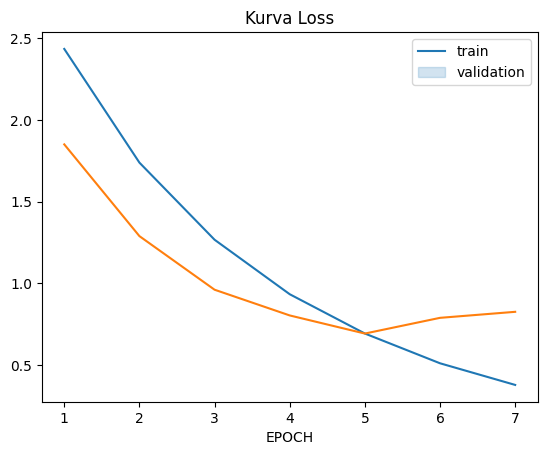

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=range(1,len(history['train_loss'])+1), y=history['train_loss'])
sns.lineplot(x=range(1,len(history['train_loss'])+1), y=history['val_loss'])
plt.legend(['train', 'validation'])
plt.xlabel("EPOCH")
plt.title("Kurva Loss")

Text(0.5, 1.0, 'Akurasi')

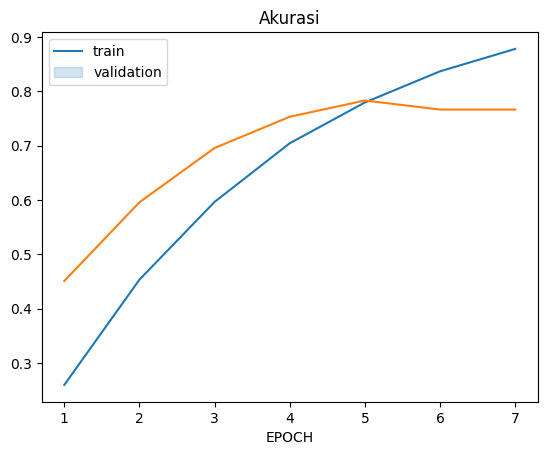

In [ ]:
sns.lineplot(x=range(1,len(history['train_loss'])+1), y=history['train_acc'])
sns.lineplot(x=range(1,len(history['train_loss'])+1), y=history['val_acc'])
plt.legend(['train', 'validation'])
plt.xlabel("EPOCH")
plt.title("Akurasi")

In [ ]:
model = model.load_state_dict(best_state)

loss, true_list, pred_list = eval_model(test_dataloader, model, loss_fn)

acc = accuracy_score(true_list.cpu().numpy(), pred_list.cpu().numpy())

print("ResNet18")
print(classification_report(true_list.cpu().numpy(), pred_list.cpu().numpy()))
print(f"val loss : {loss}, val acc : {acc}")

 12%|█▏        | 18/150 [00:01<00:09, 13.29it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 150/150 [00:10<00:00, 14.55it/s]

ResNet18
              precision    recall  f1-score   support

         0.0       0.68      0.97      0.80        63
         1.0       0.96      0.88      0.92        50
         2.0       0.87      0.91      0.89        58
         3.0       0.79      0.94      0.86        72
         4.0       0.86      0.87      0.86        69
         5.0       0.60      0.81      0.69        70
         6.0       0.85      0.83      0.84        48
         7.0       0.75      0.81      0.78        57
         8.0       0.91      0.91      0.91        58
         9.0       0.69      0.81      0.74        63
        10.0       0.75      0.30      0.43        50
        11.0       0.92      0.88      0.90        64
        12.0       0.57      0.46      0.51        61
        13.0       0.75      0.56      0.64        64
        14.0       0.68      0.86      0.76        63
        15.0       0.97      0.49      0.65        63
        16.0       0.81      0.82      0.81        56
        17.0      

In [ ]:
import json

json.dump(history, open("./flat.resnet18.json", "w"))